Problem 1: Program DFS for Undirected Graph Data Structure

We will now program an undirected graph using the adjacency list representation in Python along with some utility functions including a depth first search algorithm over undirected graphs.

Recall that a graph is undirected if for every edge  (𝑢,𝑣)
  in the graph from  𝑢
  to  𝑣
  there is also the edge in the reverse direction  (𝑣,𝑢)
  from  𝑣
  to  𝑢
 


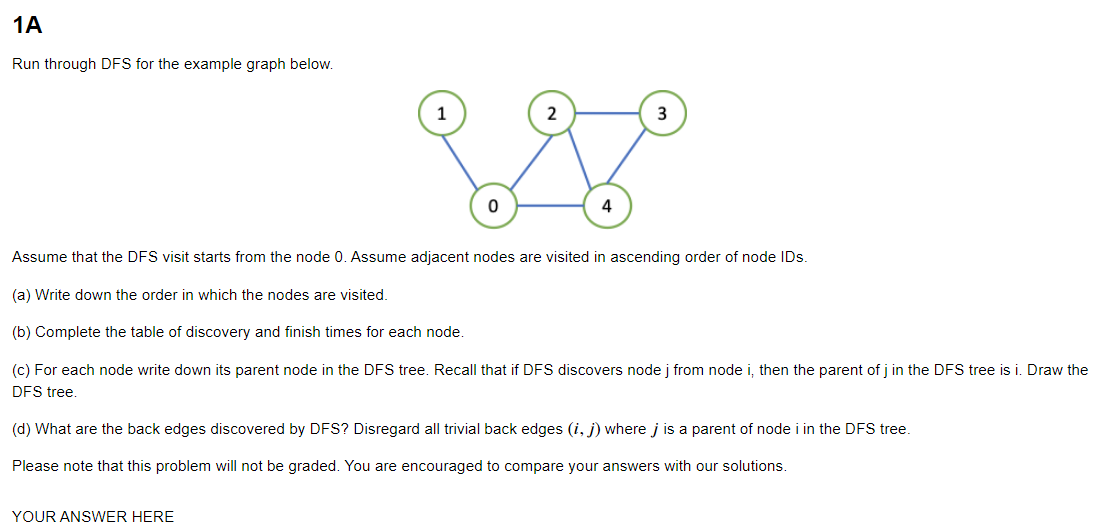

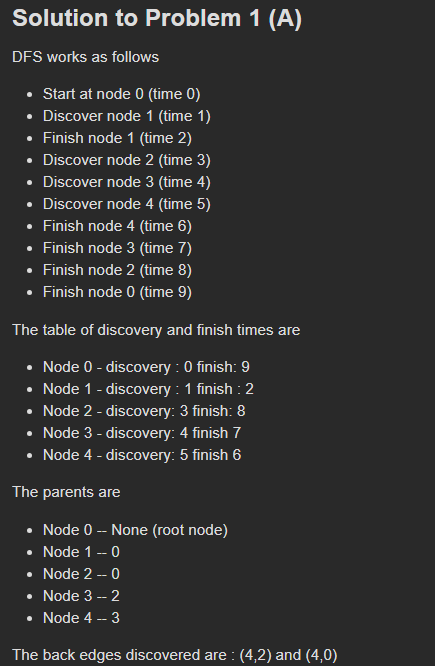

1 B

Complete the code for the dfs_visit function below.

To do so, please read the rest of the code provided and the surrounding comments very carefully.

Please ensure that the following rules are followed:

When visiting a node i, consider the set of adjacent nodes in increasing order.
This is automatically done for you when you get self.adj_list[i] which is implemented as a python set.
Use the DFSTimeCounter class provided to keep track of DFS time.
The timer should be incremented just before we return from dfs_visit and record the finish time for a node.
Recall that a back edge in a DFS is encountered whenever we visit a node i and encounter adjacent node j such that j has been discovered but not finished.
If this happens, add (i,j) to the set of back edges.
The dfs_visit code does not return anything but updates the arguments discovery_times, finish_times, dfs_tree_parent and dfs_back_edges in place.

In [9]:
# This is a useful data structure for implementing 
# a counter that counts the time.
class DFSTimeCounter:
    def __init__(self):
        self.count = 0
    
    def reset(self):
        self.count = 0
    
    def increment(self):
        self.count = self.count + 1
        
    def get(self):
        return self.count 
    
class UndirectedGraph:
    
    # n is the number of vertices
    # we will label the vertices from 0 to self.n -1 
    # Initialize to an empty adjacency list
    # We will store the outgoing edges using a set data structure
    def __init__(self, n):
        self.n = n
        self.adj_list = [ set() for i in range(self.n) ]
        
    def add_edge(self, i, j):
        assert 0 <= i < self.n
        assert 0 <= j < self.n
        assert i != j
        # Make sure to add edge from i to j
        self.adj_list[i].add(j)
        # Also add edge from j to i
        self.adj_list[j].add(i)
        
    # get a set of all vertices that 
    # are neighbors of the
    # vertex i
    def get_neighboring_vertices(self, i):
        assert 0 <= i < self.n
        return self.adj_list[i]
    
    # Function: dfs_visit
    # Program a DFS visit of a graph.
    # We maintain a list of discovery times and finish times.
    # Initially all discovery times and finish times are set to None.
    # When a vertex is first visited, we will set discovery time
    # When DFS visit has processed all the neighbors then 
    # set the finish time.
    # DFS visit should update the list of discovery and finish times in-place
    # Arguments
    #  i --> id of the vertex being visited.
    #  dfs_timer --> An instance of DFSTimeCounter structure provided for you.
    #  discovery --> discovery time of each vertex -- a list of size self.n
    #                None if the vertex is yet to be visited.
    #  finish --> finish time of each vertex -- a list of size self.n
    #                None if the vertex is yet to be finished.
    #  dfs_tree_parent --> the parent for for each node 
    #                       if we visited node j from node i, then j's parent is i.
    #                      Do not forget to set tree_parent when you call dfs_visit 
    #                                                         on node j from node i.
    #  dfs_back_edges --> a list of back edges.
    #                     a back edge is an edge from i to j wherein
    #                     DFS has already discovered j when i is discovered 
    #                                     but not finished j
    
    def dfs_visit(self, i, dfs_timer, discovery_times, finish_times, 
                        dfs_tree_parent, dfs_back_edges):
        assert 0 <= i < self.n
        assert discovery_times[i] == None
        assert finish_times[i] == None
        discovery_times[i] = dfs_timer.get()
        dfs_timer.increment()
        # your code here
        neighbors = self.get_neighboring_vertices(i)
        for neighbor in neighbors:
            if discovery_times[neighbor] == None:
                dfs_tree_parent[neighbor] = i
                self.dfs_visit(neighbor, dfs_timer, discovery_times, finish_times, 
                        dfs_tree_parent, dfs_back_edges)
                finish_times[neighbor] = dfs_timer.get()
                dfs_timer.increment()
            else:
                # check if neighbor is back egde and add to list
                if discovery_times[i] > discovery_times[neighbor] and finish_times[neighbor] == None :
                    dfs_back_edges.append((i, neighbor))
        
    
    # Function: dfs_traverse_graph
    # Traverse the entire graph.
    def dfs_traverse_graph(self):
        dfs_timer = DFSTimeCounter()
        discovery_times = [None]*self.n
        finish_times = [None]*self.n
        dfs_tree_parents = [None]*self.n
        dfs_back_edges = []
        for i in range(self.n):
            if discovery_times[i] == None:
                self.dfs_visit(i,dfs_timer, discovery_times, finish_times, 
                               dfs_tree_parents, dfs_back_edges)
        # Clean up the back edges so that if (i,j) is a back edge then j cannot
        # be i's parent.
        non_trivial_back_edges = [(i,j) for (i,j) in dfs_back_edges if dfs_tree_parents[i] != j]
        return (dfs_tree_parents, non_trivial_back_edges, discovery_times, finish_times)

    

In [10]:
# create the graph from problem 1A.
g = UndirectedGraph(5)
g.add_edge(0,1)
g.add_edge(0,2)
g.add_edge(0,4)
g.add_edge(2,3)
g.add_edge(2,4)
g.add_edge(3,4)


# Test DFS visit
discovery_times = [None]*5
finish_times = [None]*5
dfs_tree_parents = [None]*5
dfs_back_edges = []
g.dfs_visit(0, DFSTimeCounter(), discovery_times, finish_times, dfs_tree_parents, dfs_back_edges )

print('DFS visit discovery and finish times given by your code.')
print('Node\t Discovery\t Finish')
for i in range(5):
    print(f'{i} \t {discovery_times[i]}\t\t {finish_times[i]}')

assert(discovery_times[0] == 0), f'Fail: Node 0 expected discovery time must be 0'
assert(discovery_times[1] == 1), f'Fail: Node 1 expected discovery is 1'
assert(finish_times[1] == 2), f'Fail: Node 1 finish time expected value is 2 (are you incrementing counter before you return from dfs_visit function and before recording finish times)'
assert(discovery_times[2] == 3), f'Fail: Node 2 expected discovery is 3'
assert(finish_times[2] == 8), f'Fail: Node 2 finish time expected value is 8'
assert(discovery_times[3] == 4),f'Fail: Node 3 discovery time expected value is 4'
assert(finish_times[3] == 7), f'Fail: Node 3 finish time expected value is 7'
assert(discovery_times[4] == 5),f'Fail: Node 4 discovery time expected value is 5'
assert(finish_times[4] == 6), f'Fail: Node 4 finish time expected value is 6'

print('Success -- discovery and finish times seem correct.')
print()
    
print('Node\t DFS-Tree-Parent')
for i in range(5):
    print(f'{i} \t {dfs_tree_parents[i]}')

assert(dfs_tree_parents[0] == None), 'Fail: node 0 cannot have a parent (must be root)'
assert(dfs_tree_parents[1] == 0), 'Fail: node 1 parent must be 0'
assert(dfs_tree_parents[2] == 0), 'Fail: node 2 parent must be 0'
assert(dfs_tree_parents[3] == 2), 'Fail: node 3 parent must be 2'
assert(dfs_tree_parents[4] == 3), 'Fail: node 4 parent must be 3'

print('Success-- DFS parents are set correctly.')


print()
# Filter out all trivial back eddges (i,j)  where j is simply the parent of i.
# such back edges occur because we are treating an undirected edge as two directed edges
# in either direction.
non_trivial_back_edges = [(i,j) for (i,j) in dfs_back_edges if dfs_tree_parents[i] != j]
print('Back edges are')
for (i,j) in non_trivial_back_edges:
    print(f'{(i,j)}')
    
    
assert len(non_trivial_back_edges) == 2, f'Fail: There must be 2 non trivial back edges -- your code reports {len(non_trivial_back_edges)}. Note that (4,0) and (4,2) are the only non trivial backedges'
assert (4,2) in non_trivial_back_edges, '(4,2) must be a backedge that is non trivial'
assert (4,0) in non_trivial_back_edges, '(4,3) must be a non-trivial backedges'

print('Success -- 15 points!')

DFS visit discovery and finish times given by your code.
Node	 Discovery	 Finish
0 	 0		 None
1 	 1		 2
2 	 3		 8
3 	 4		 7
4 	 5		 6
Success -- discovery and finish times seem correct.

Node	 DFS-Tree-Parent
0 	 None
1 	 0
2 	 0
3 	 2
4 	 3
Success-- DFS parents are set correctly.

Back edges are
(4, 0)
(4, 2)
Success -- 15 points!


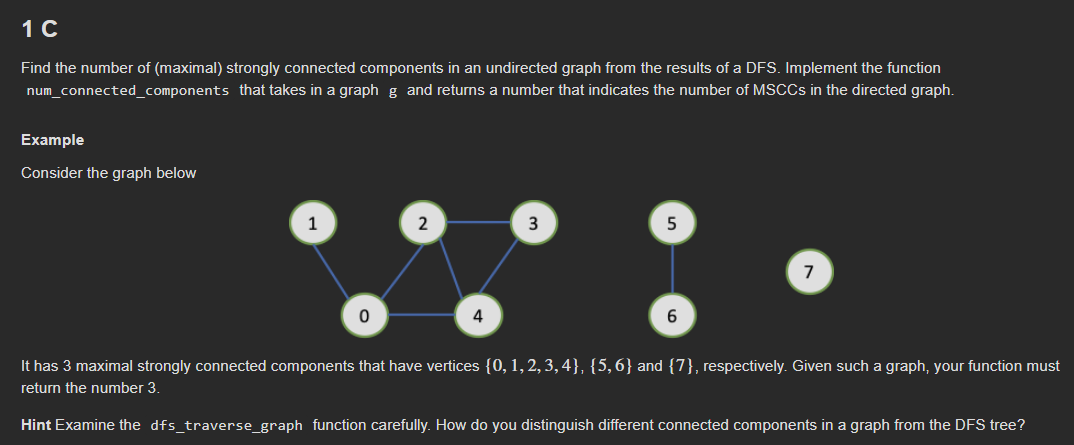

In [18]:
# Since this is undirected graph any set of connected vertices will be SCC. If we iterate over all vertices that have their parent = None (source verticves) and generate DFS tree of each of these vertices (along the way some of these may get marked visited) and then count total number of dfs_traversals called it will give total number of MSCC

def DFS(g, visited, start_node):
    if visited[start_node] != None:
        return
    visited[start_node] = 1
    for neighbor in g.get_neighboring_vertices(start_node):
        DFS(g, visited, neighbor)
        



def num_connected_components(g): # g is an UndirectedGraph class
    # your code here
    # Test DFS visit
    discovery_times = [None]*g.n
    finish_times = [None]*g.n
    dfs_tree_parents = [None]*g.n
    dfs_back_edges = []
    visited = [None]*g.n
    total = 0
    g.dfs_visit(0, DFSTimeCounter(), discovery_times, finish_times, dfs_tree_parents, dfs_back_edges )
    current_parent = -1
    for node in dfs_tree_parents:
        current_parent = current_parent + 1
        if node == None and visited[current_parent] == None: # no parent and not visited yet
            total = total + 1
            DFS(g, visited, current_parent)
    return total


In [22]:
# create the graph from problem 1A.
g = UndirectedGraph(5)
g.add_edge(0,1)
g.add_edge(0,2)
g.add_edge(0,4)
g.add_edge(2,3)
g.add_edge(2,4)
g.add_edge(3,4)

assert num_connected_components(g) == 1, f' Test A failed: g must have 1 connected component. Your code returns {num_connected_components(g)}'


g2 = UndirectedGraph(7)
g2.add_edge(0,1)
g2.add_edge(0,2)
g2.add_edge(0,4)
g2.add_edge(2,3)
g2.add_edge(2,4)
g2.add_edge(3,4)
g2.add_edge(5,6)

assert num_connected_components(g2) == 2, f' Test B failed: g2 must have 2 connected components. Your code returns {num_connected_components(g2)}'


g3 = UndirectedGraph(8)
g3.add_edge(0,1)
g3.add_edge(0,2)
g3.add_edge(0,4)
g3.add_edge(2,3)
g3.add_edge(2,4)
g3.add_edge(3,4)
g3.add_edge(5,6)

assert num_connected_components(g3) == 3, f' Test C failed: g3 must have 3 connected components. Your code returns {num_connected_components(g3)}'

g3.add_edge(7,5)
assert num_connected_components(g3) == 2, f' Test D failed: g3 must now have 2 connected components. Your code returns {num_connected_components(g3)}'



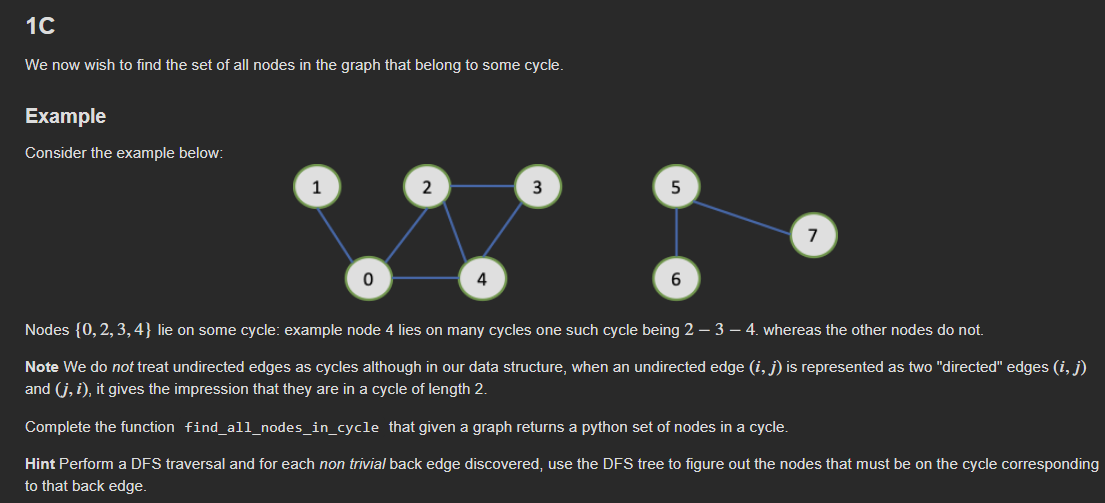

In [48]:

def get_cycle_from_backedge(back_edge, dfs_tree_parents):
    (child, ancestor) = back_edge
    # get all nodes from ancestor to child
    set_of_nodes = set()
    current = child
    set_of_nodes.add(current)
    while current != ancestor:
        current = dfs_tree_parents[current]
        set_of_nodes.add(current)
    return set_of_nodes

def find_all_nodes_in_cycle(g): # g is an UndirectedGraph class
    (dfs_tree_parents, non_trivial_back_edges, discovery_times, finish_times) = g.dfs_traverse_graph()
    set_of_nodes = set()
    for back_edge in non_trivial_back_edges:
        print (back_edge)
        tmp_nodes = get_cycle_from_backedge(back_edge, dfs_tree_parents)
        for node in tmp_nodes:
            set_of_nodes.add(node)
    return set_of_nodes

In [49]:
#this is the example that we had for the problem.
g3 = UndirectedGraph(8)
g3.add_edge(0,1)
g3.add_edge(0,2)
g3.add_edge(0,4)
g3.add_edge(2,3)
g3.add_edge(2,4)
g3.add_edge(3,4)
g3.add_edge(5,6)
g3.add_edge(5,7)

s = find_all_nodes_in_cycle(g3)
print(f'Your code returns set of nodes: {s}')
assert s == {0,2,3,4}, 'Fail: Set of nodes must be {0,2,3,4}.'

# let's also add the edge 6,7
g3.add_edge(6,7)
s1 = find_all_nodes_in_cycle(g3)
print(f'Your code returns set of nodes: {s1}')
assert s1 == {0,2,3,4,5,6,7}, 'Fail: Set of nodes must be {0,2,3,4,5,6,7}.'

print('All tests passedd: 10 points!')

(4, 0)
(4, 2)
Your code returns set of nodes: {0, 2, 3, 4}
(4, 0)
(4, 2)
(7, 5)
Your code returns set of nodes: {0, 2, 3, 4, 5, 6, 7}
All tests passedd: 10 points!
